# CASALS public S3 data inventory

This notebook inventories object metadata under the public **casals-data/lidar/** prefix using anonymous, paginated S3 **ListObjectsV2** requests. It never downloads or reads object contents. **HeadObject** checks are opt-in and run only for explicitly named keys.

The listing is limited to this public prefix. Product levels are recognized from explicit filename markers; **LastModified** is not treated as an acquisition date. Source: [NASA CASALS L1B Waveform Data Tutorial](https://book.cryointhecloud.com/l1b-waveforms-tutorial/).

Requires **boto3**, **pandas**, and **matplotlib** (install with **python -m pip install boto3 pandas matplotlib** if needed). Run from the project root or any working directory; no project modules or AWS credentials are used.

## Connect and list all objects

The paginator follows every continuation token. Directory placeholders with zero size are omitted; real zero-byte objects are retained. A failed page leaves the inventory explicitly incomplete and stops downstream summaries.

In [1]:
from datetime import date, datetime, timezone
from pathlib import Path, PurePosixPath
import re

import boto3
import matplotlib.pyplot as plt
import pandas as pd
from botocore import UNSIGNED
from botocore.config import Config
from botocore.exceptions import BotoCoreError, ClientError
from IPython.display import display

BUCKET = "casals-data"
PREFIX = "lidar/"
BYTES_PER_GIB = 2**30
BYTES_PER_TIB = 2**40
RUN_HEAD_CHECK = False
HEAD_CHECK_KEYS = []  # Exact S3 keys only; never populate this from the full inventory.

s3 = boto3.client(
    "s3",
    region_name="us-west-2",
    config=Config(signature_version=UNSIGNED),
)

ALLOWED_S3_OPERATIONS = {"ListObjectsV2"} | ({"HeadObject"} if RUN_HEAD_CHECK else set())
def enforce_allowed_s3_operations(model, **kwargs):
    if model.name not in ALLOWED_S3_OPERATIONS:
        raise RuntimeError(f"Blocked unexpected S3 operation: {model.name}")
s3.meta.events.register("before-call.s3", enforce_allowed_s3_operations)


def rows_from_pages(pages):
    """Flatten ListObjectsV2 pages, excluding only zero-byte folder markers."""
    for page in pages:
        for obj in page.get("Contents", []):
            key, size = obj["Key"], int(obj["Size"])
            if key.endswith("/") and size == 0:
                continue
            yield {
                "Key": key,
                "Size (bytes)": size,
                "LastModified": obj.get("LastModified"),
                "StorageClass": obj.get("StorageClass"),
            }


_fixture = list(rows_from_pages([
    {"Contents": [{"Key": "lidar/2024-01-01/", "Size": 0},
                   {"Key": "lidar/2024-01-01/a.h5", "Size": 12}]},
    {"Contents": [{"Key": "lidar/zero.bin", "Size": 0}]},
]))
assert [row["Key"] for row in _fixture] == ["lidar/2024-01-01/a.h5", "lidar/zero.bin"]
assert sum(row["Size (bytes)"] for row in _fixture) == 12

paginator = s3.get_paginator("list_objects_v2")
page_count = 0
object_rows = []
inventory_complete = False
try:
    for page in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX):
        page_count += 1
        object_rows.extend(rows_from_pages([page]))
    inventory_complete = True
except (ClientError, BotoCoreError) as exc:
    code = (exc.response.get("Error", {}).get("Code", "Unknown")
            if isinstance(exc, ClientError) else type(exc).__name__)
    print(f"INVENTORY INCOMPLETE: ListObjectsV2 failed [{code}]. No live totals or empty inventory are reported.")
    raise RuntimeError("Live S3 inventory is incomplete; rerun after access/network is restored.") from exc

if not inventory_complete:
    raise RuntimeError("Live S3 inventory did not complete; downstream summaries are unavailable.")
inventory_timestamp_utc = datetime.now(timezone.utc)
print(f"Completed {page_count} ListObjectsV2 page(s); retained {len(object_rows):,} non-placeholder object(s).")

Completed 27 ListObjectsV2 page(s); retained 26,418 non-placeholder object(s).


## Parse metadata and classify names

Acquisition dates come only from a valid **lidar/YYYY-MM-DD/** directory. Product levels come only from explicit, case-insensitive filename markers. Other files remain in the inventory.

In [2]:
LEVEL_ORDER = ["L0", "L1A", "L1B", "L2A", "L2B", "ARD", "Other / Unknown"]
PRODUCT_PATTERN = re.compile(r"(?<![A-Z0-9])(L1A|L1B|L2A|L2B|L0|ARD)(?![A-Z0-9])", re.IGNORECASE)
LEVEL2_PATTERN = re.compile(
    r"(?<![A-Z0-9])(?:L2(?:[A-Z])?|LEVEL[\s_-]*2(?:[A-Z])?)(?![A-Z0-9])",
    re.IGNORECASE,
)

def acquisition_date_from_key(key):
    relative_key = key[len(PREFIX):] if key.startswith(PREFIX) else key
    if "/" not in relative_key:
        return "Unknown"
    directory = relative_key.split("/", 1)[0]
    if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", directory):
        return "Unknown"
    try:
        return date.fromisoformat(directory).isoformat()
    except ValueError:
        return "Unknown"

def product_level_from_name(filename):
    match = PRODUCT_PATTERN.search(filename)
    if not match:
        return "Other / Unknown"
    return match.group(1).upper()

def has_explicit_level2_marker(filename):
    return bool(LEVEL2_PATTERN.search(filename))

assert acquisition_date_from_key("lidar/2024-02-29/a.h5") == "2024-02-29"
assert acquisition_date_from_key("lidar/2023-02-29/a.h5") == "Unknown"
assert acquisition_date_from_key("lidar/a.h5") == "Unknown"
assert product_level_from_name("casals_L1B_file.h5") == "L1B"
assert product_level_from_name("casals_L1BS_file.h5") == "Other / Unknown"
assert has_explicit_level2_marker("product_LEVEL-2A.tif")
assert not has_explicit_level2_marker("product_L20.tif")

inventory = pd.DataFrame(
    object_rows,
    columns=["Key", "Size (bytes)", "LastModified", "StorageClass"],
)
inventory["Size (bytes)"] = pd.to_numeric(inventory["Size (bytes)"], errors="raise").astype("int64")
inventory["Acquisition date"] = inventory["Key"].map(acquisition_date_from_key)
inventory["Product level"] = inventory["Key"].map(
    lambda key: product_level_from_name(PurePosixPath(key).name)
)
inventory["File format"] = inventory["Key"].map(
    lambda key: PurePosixPath(key).suffix.lower() or "No extension"
)
inventory["Explicit Level-2 marker"] = inventory["Key"].map(
    lambda key: has_explicit_level2_marker(PurePosixPath(key).name)
)

total_bytes = int(inventory["Size (bytes)"].sum())
assert len(inventory) == len(object_rows)
assert total_bytes == sum(row["Size (bytes)"] for row in object_rows)
print(f"Inventory DataFrame: {len(inventory):,} objects; {total_bytes:,} bytes.")

Inventory DataFrame: 26,418 objects; 3,432,133,618,446 bytes.


## A. Storage overview

Recognized acquisition-date totals exclude **Unknown**; the date range is not inferred from S3 modification timestamps.

In [3]:
known_dates = sorted(d for d in inventory["Acquisition date"].unique() if d != "Unknown")
observed_levels = [level for level in LEVEL_ORDER if level != "Other / Unknown" and level in set(inventory["Product level"])]
if "Other / Unknown" in set(inventory["Product level"]):
    observed_levels.append("Other / Unknown")

overview = pd.DataFrame(
    [
        ("Bucket", BUCKET),
        ("Query prefix", PREFIX),
        ("Inventory timestamp (UTC)", inventory_timestamp_utc.isoformat()),
        ("ListObjectsV2 pages", page_count),
        ("Objects (zero-byte directory placeholders excluded)", len(inventory)),
        ("Total size (bytes)", f"{total_bytes:,}"),
        ("Total size (GiB, 2^30 bytes)", f"{total_bytes / BYTES_PER_GIB:,.3f}"),
        ("Total size (TiB, 2^40 bytes)", f"{total_bytes / BYTES_PER_TIB:,.4f}"),
        ("Earliest acquisition date", known_dates[0] if known_dates else "Unknown"),
        ("Latest acquisition date", known_dates[-1] if known_dates else "Unknown"),
        ("Distinct recognized acquisition dates", len(known_dates)),
        ("Product levels observed", ", ".join(observed_levels) if observed_levels else "None identified"),
    ],
    columns=["Measure", "Value"],
)
display(overview)

,Measure,Value
0,Bucket,casals-data
1,Query prefix,lidar/
2,Inventory timestamp (UTC),2026-10-11T02:30:48.903020+00:00
3,ListObjectsV2 pages,27
4,Objects (zero-byte directory placeholders excl...,26418
5,Total size (bytes),"3,432,133,618,446"
6,"Total size (GiB, 2^30 bytes)","3,196.424"
7,"Total size (TiB, 2^40 bytes)",3.1215
8,Earliest acquisition date,2024-11-12
9,Latest acquisition date,2024-11-18


## B. Inventory by product level

Percentages use the total listed object size. Standard levels with no matches remain visible with zero values; this says nothing about other buckets or non-public storage.

In [4]:
product_summary = (
    inventory.groupby("Product level", dropna=False)
    .agg(**{"Number of files": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .reindex(LEVEL_ORDER, fill_value=0)
)
product_summary["Total size (GiB)"] = product_summary["Total size (bytes)"] / BYTES_PER_GIB
product_summary["Percentage of storage"] = (
    100 * product_summary["Total size (bytes)"] / total_bytes if total_bytes else 0.0
)
product_summary = product_summary[
    ["Number of files", "Total size (GiB)", "Percentage of storage"]
].reset_index(names="Product level")
product_summary["Total size (GiB)"] = product_summary["Total size (GiB)"].round(3)
product_summary["Percentage of storage"] = product_summary["Percentage of storage"].round(2)
assert int(product_summary["Number of files"].sum()) == len(inventory)
display(product_summary)

format_summary = (
    inventory.groupby("File format", dropna=False)
    .agg(**{"Number of files": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .sort_values("Total size (bytes)", ascending=False)
)
format_summary["Total size (GiB)"] = (format_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
format_summary = format_summary[["Number of files", "Total size (GiB)"]].reset_index()
print("File-format summary")
display(format_summary)

,Product level,Number of files,Total size (GiB),Percentage of storage
0,L0,0,0.000,0.00
1,L1A,0,0.000,0.00
2,L1B,26409,3153.387,98.65
3,L2A,0,0.000,0.00
4,L2B,0,0.000,0.00
5,ARD,0,0.000,0.00
6,Other / Unknown,9,43.037,1.35


File-format summary


,File format,Number of files,Total size (GiB)
0,.h5,273,3135.061
1,.m4v,4,43.001
2,.png,18936,18.322
3,.kml,7204,0.040
4,.txt,1,0.000


## C. Inventory by acquisition date

The date summary includes an **Unknown** row when a key has no valid date directory. The cross-tab reports file counts for each product level and date.

Files and storage by acquisition date


,Acquisition date,File count,Total size (GiB)
0,2024-11-12,6296,1114.586
1,2024-11-18,10687,2023.426
2,Unknown,9435,58.412


File count by acquisition date and product level


Product level,Acquisition date,L0,L1A,L1B,L2A,L2B,ARD,Other / Unknown
0,2024-11-12,0,0,6296,0,0,0,0
1,2024-11-18,0,0,10687,0,0,0,0
2,Unknown,0,0,9426,0,0,0,9


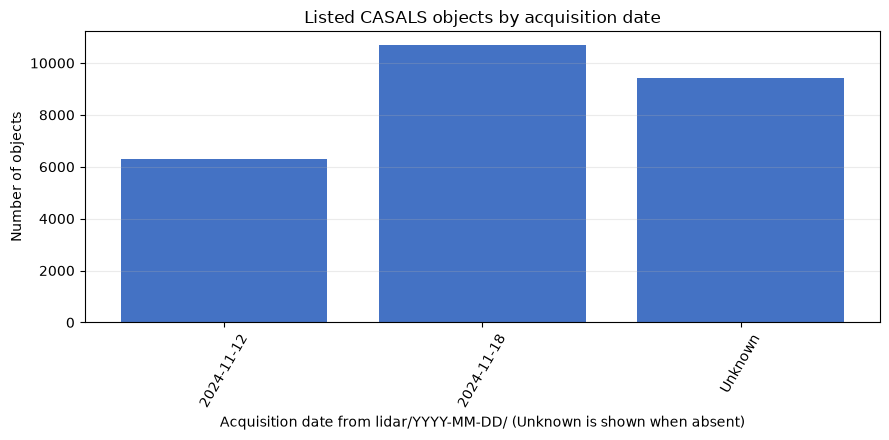

In [5]:
date_summary = (
    inventory.groupby("Acquisition date", dropna=False)
    .agg(**{"File count": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
)
date_summary["Total size (GiB)"] = (date_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
date_summary = date_summary[["File count", "Total size (GiB)"]].reset_index()

date_level_counts = pd.crosstab(inventory["Acquisition date"], inventory["Product level"])
date_level_counts = date_level_counts.reindex(columns=LEVEL_ORDER, fill_value=0)
date_order = known_dates + (["Unknown"] if "Unknown" in set(inventory["Acquisition date"]) else [])
date_summary = date_summary.set_index("Acquisition date").reindex(date_order).reset_index()
date_level_counts = date_level_counts.reindex(date_order, fill_value=0)

print("Files and storage by acquisition date")
display(date_summary)
print("File count by acquisition date and product level")
display(date_level_counts.reset_index())

if len(date_summary):
    chart_width = min(22, max(9, 0.42 * len(date_summary)))
    fig, ax = plt.subplots(figsize=(chart_width, 4.5))
    ax.bar(date_summary["Acquisition date"], date_summary["File count"], color="#4472C4")
    ax.set_title("Listed CASALS objects by acquisition date")
    ax.set_xlabel("Acquisition date from lidar/YYYY-MM-DD/ (Unknown is shown when absent)")
    ax.set_ylabel("Number of objects")
    ax.grid(axis="y", alpha=0.25)
    tick_step = max(1, len(date_summary) // 24)
    ax.set_xticks(range(0, len(date_summary), tick_step))
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    plt.show()
else:
    print("No non-placeholder objects were returned for this prefix.")

## D. Directory structure

This groups every listed object under its immediate child of **lidar/**. Files directly in **lidar/** are shown as root objects.

In [6]:
def immediate_child(key):
    relative_key = key[len(PREFIX):] if key.startswith(PREFIX) else key
    if "/" not in relative_key:
        return f"{PREFIX}(root)"
    return f"{PREFIX}{relative_key.split('/', 1)[0]}/"

inventory["Immediate child prefix"] = inventory["Key"].map(immediate_child)
directory_summary = (
    inventory.groupby("Immediate child prefix", dropna=False)
    .agg(**{"Object count": ("Key", "size"), "Total size (bytes)": ("Size (bytes)", "sum")})
    .sort_values(["Object count", "Total size (bytes)"], ascending=False)
)
directory_summary["Total size (GiB)"] = (directory_summary["Total size (bytes)"] / BYTES_PER_GIB).round(3)
directory_summary = directory_summary[["Object count", "Total size (GiB)"]].reset_index()
assert int(directory_summary["Object count"].sum()) == len(inventory)
display(directory_summary)

,Immediate child prefix,Object count,Total size (GiB)
0,lidar/2024-11-18/,10687,2023.426
1,lidar/Google_Earth_Tour/,9431,15.411
2,lidar/2024-11-12/,6296,1114.586
3,lidar/(root),4,43.001


## E. File inventory

**s3_inventory** retains all listed object metadata and parsed fields for interactive filtering. The default preview is limited to 20 rows.

In [7]:
s3_inventory = inventory.copy()
with pd.option_context("display.max_colwidth", None):
    display(s3_inventory.head(20))

largest_columns = ["Key", "Product level", "Acquisition date", "Size (bytes)", "LastModified"]
largest_20 = s3_inventory.nlargest(20, "Size (bytes)")[largest_columns].copy()
largest_20["Size (GiB)"] = (largest_20["Size (bytes)"] / BYTES_PER_GIB).round(3)
largest_20 = largest_20[["Key", "Product level", "Acquisition date", "Size (GiB)", "LastModified"]]
print("20 largest listed objects")
with pd.option_context("display.max_colwidth", None):
    display(largest_20)

,Key,Size (bytes),LastModified,StorageClass,Acquisition date,Product level,File format,Explicit Level-2 marker,Immediate child prefix
0,lidar/2024-11-12/casals_l1b_20241112T163923_001_02.h5,3265927272,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
1,lidar/2024-11-12/casals_l1b_20241112T163934_001_02.h5,1400700828,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
2,lidar/2024-11-12/casals_l1b_20241112T163941_001_02.h5,1686318835,2025-12-11 15:02:45+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
3,lidar/2024-11-12/casals_l1b_20241112T164250_001_02.h5,13937434321,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
4,lidar/2024-11-12/casals_l1b_20241112T164315_001_02.h5,13902043088,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
5,lidar/2024-11-12/casals_l1b_20241112T164340_001_02.h5,13874478868,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
6,lidar/2024-11-12/casals_l1b_20241112T164406_001_02.h5,13976438011,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
7,lidar/2024-11-12/casals_l1b_20241112T164431_001_02.h5,13963454127,2025-12-11 15:09:39+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
8,lidar/2024-11-12/casals_l1b_20241112T164456_001_02.h5,1019179723,2025-12-11 15:18:02+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/
9,lidar/2024-11-12/casals_l1b_20241112T164916_001_02.h5,13944626497,2025-12-11 15:18:46+00:00,INTELLIGENT_TIERING,2024-11-12,L1B,.h5,False,lidar/2024-11-12/


20 largest listed objects


,Key,Product level,Acquisition date,Size (GiB),LastModified
16985,lidar/CASALS_2024-11-18_All_Amplitudes_Tour.m4v,Other / Unknown,Unknown,14.008,2026-01-20 18:35:40+00:00
16986,lidar/CASALS_2024-11-18_All_Heights_Tour.m4v,Other / Unknown,Unknown,13.996,2026-01-20 18:35:40+00:00
6420,lidar/2024-11-18/casals_l1b_20241118T172515_001_02.h5,L1B,2024-11-18,13.185,2025-12-12 17:06:06+00:00
11,lidar/2024-11-12/casals_l1b_20241112T165006_001_02.h5,L1B,2024-11-12,13.152,2025-12-11 15:20:13+00:00
38,lidar/2024-11-12/casals_l1b_20241112T171847_001_02.h5,L1B,2024-11-12,13.134,2025-12-11 16:10:09+00:00
6421,lidar/2024-11-18/casals_l1b_20241118T172541_001_02.h5,L1B,2024-11-18,13.134,2025-12-12 17:07:37+00:00
6411,lidar/2024-11-18/casals_l1b_20241118T171757_001_02.h5,L1B,2024-11-18,13.115,2025-12-12 16:49:55+00:00
6406,lidar/2024-11-18/casals_l1b_20241118T171552_001_02.h5,L1B,2024-11-18,13.114,2025-12-12 16:39:44+00:00
6413,lidar/2024-11-18/casals_l1b_20241118T172006_001_02.h5,L1B,2024-11-18,13.112,2025-12-12 16:56:01+00:00
25,lidar/2024-11-12/casals_l1b_20241112T170442_001_02.h5,L1B,2024-11-12,13.104,2025-12-11 15:47:54+00:00


## F. Check two locally used H5 filenames

This lookup uses inventory key basenames only and does not inspect any local or remote H5 contents.

In [8]:
historical_sizes = {
    "casals_l1b_20241112T165718_001_02.h5": 14_039_701_685,
    "casals_l1b_20241118T171757_001_02.h5": 14_082_437_919,
}
lookup_rows = []
for filename, historical_size in historical_sizes.items():
    matches = s3_inventory[
        s3_inventory["Key"].map(lambda key: PurePosixPath(key).name == filename)
    ]
    local_path = Path("data/raw/casals_l1b") / filename
    local_exists = local_path.is_file()
    local_size = local_path.stat().st_size if local_exists else None
    if matches.empty:
        lookup_rows.append({
            "Filename": filename,
            "S3 match": "not found in completed prefix listing",
            "S3 Key": None,
            "S3 size (bytes)": None,
            "Local file": str(local_path) if local_exists else "not checked: local file absent",
            "Local size (bytes)": local_size,
            "Historical size (bytes)": historical_size,
        })
    else:
        for _, match in matches.iterrows():
            lookup_rows.append({
                "Filename": filename,
                "S3 match": "found by exact basename",
                "S3 Key": match["Key"],
                "S3 size (bytes)": int(match["Size (bytes)" ]),
                "S3 size matches local": (int(match["Size (bytes)"]) == local_size) if local_exists else "not checked",
                "Local file": str(local_path) if local_exists else "not checked: local file absent",
                "Local size (bytes)": local_size,
                "Historical size (bytes)": historical_size,
                "S3 size matches corrected history": int(match["Size (bytes)"]) == historical_size,
            })
local_file_lookup = pd.DataFrame(lookup_rows)
with pd.option_context("display.max_colwidth", None):
    display(local_file_lookup)

print(
    "The earlier notebook record had the two historical file sizes assigned to the opposite dates. "
    "The corrected values above match each local file's current stat size. Filename and size "
    "correspondence does not establish the route by which a local file was downloaded."
)

,Filename,S3 match,S3 Key,S3 size (bytes),S3 size matches local,Local file,Local size (bytes),Historical size (bytes),S3 size matches corrected history
0,casals_l1b_20241112T165718_001_02.h5,found by exact basename,lidar/2024-11-12/casals_l1b_20241112T165718_001_02.h5,14039701685,True,data\raw\casals_l1b\casals_l1b_20241112T165718_001_02.h5,14039701685,14039701685,True
1,casals_l1b_20241118T171757_001_02.h5,found by exact basename,lidar/2024-11-18/casals_l1b_20241118T171757_001_02.h5,14082437919,True,data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5,14082437919,14082437919,True


The earlier notebook record had the two historical file sizes assigned to the opposite dates. The corrected values above match each local file's current stat size. Filename and size correspondence does not establish the route by which a local file was downloaded.


## G. Level-2 availability

Level-2 detection checks explicit filename markers such as **L2**, **L2A**, **L2B**, or **LEVEL-2**. The search scope is only this public S3 prefix.

In [9]:
level2_inventory = s3_inventory[s3_inventory["Explicit Level-2 marker"]].copy()

if level2_inventory.empty:
    print("No explicitly labeled Level-2 object was identified in the scanned public prefix.")
else:
    level2_display = level2_inventory[
        ["Key", "Product level", "Size (bytes)", "LastModified", "Acquisition date"]
    ].copy()
    level2_display["Size (GiB)"] = (level2_display["Size (bytes)"] / BYTES_PER_GIB).round(3)
    print(f"Identified {len(level2_display):,} object(s) with an explicit Level-2 filename marker under {BUCKET}/{PREFIX}.")
    with pd.option_context("display.max_colwidth", None):
        display(level2_display[["Key", "Product level", "Size (bytes)", "Size (GiB)", "LastModified", "Acquisition date"]])

No explicitly labeled Level-2 object was identified in the scanned public prefix.


## H. Optional object read-access checks

By default, this notebook makes no **HeadObject** requests. To check a small, explicit selection, set `RUN_HEAD_CHECK = True` and add exact keys to `HEAD_CHECK_KEYS` in the connection cell. A successful response confirms current metadata-read authorization; it does not test a byte transfer or file integrity. The default inventory uses only `ListObjectsV2`. See the [AWS HeadObject API](https://docs.aws.amazon.com/AmazonS3/latest/API/API_HeadObject.html).

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed

HEAD_WORKERS = 8
head_rows = s3_inventory[s3_inventory["Key"].isin(HEAD_CHECK_KEYS)][["Key", "Size (bytes)", "StorageClass"]].to_dict("records")

def check_object_read_access(row):
    try:
        response = s3.head_object(Bucket=BUCKET, Key=row["Key"])
        http_status = response.get("ResponseMetadata", {}).get("HTTPStatusCode")
        storage_class = response.get("StorageClass") or row["StorageClass"]
        archive_status = response.get("ArchiveStatus")
        restore_status = response.get("Restore")
        archived = (
            storage_class in {"GLACIER", "DEEP_ARCHIVE"}
            or archive_status in {"ARCHIVE_ACCESS", "DEEP_ARCHIVE_ACCESS"}
        )
        if not archived:
            availability = "Readable now"
        elif restore_status and re.search(r'ongoing-request\s*=\s*"false"', restore_status, re.IGNORECASE):
            availability = "Restored; readable temporarily"
        elif restore_status and re.search(r'ongoing-request\s*=\s*"true"', restore_status, re.IGNORECASE):
            availability = "Restore in progress"
        else:
            availability = "Archived; not currently readable"

        return {
            "Key": row["Key"],
            "HeadObject status": "Success" if http_status == 200 else f"HTTP {http_status}",
            "HTTP status": http_status,
            "Error code": None,
            "Error message": None,
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": response.get("ContentLength"),
            "Size matches listing": response.get("ContentLength") == int(row["Size (bytes)"]),
            "StorageClass": storage_class,
            "ArchiveStatus": archive_status,
            "Restore": restore_status,
            "Availability now": availability,
        }
    except ClientError as exc:
        error = exc.response.get("Error", {})
        metadata = exc.response.get("ResponseMetadata", {})
        code = error.get("Code", "Unknown")
        http_status = metadata.get("HTTPStatusCode")
        return {
            "Key": row["Key"],
            "HeadObject status": "Access denied" if http_status == 403 or code == "AccessDenied" else "Request failed",
            "HTTP status": http_status,
            "Error code": code,
            "Error message": error.get("Message", str(exc)),
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": None,
            "Size matches listing": None,
            "StorageClass": row["StorageClass"],
            "ArchiveStatus": None,
            "Restore": None,
            "Availability now": "Unknown",
        }
    except BotoCoreError as exc:
        return {
            "Key": row["Key"],
            "HeadObject status": "Request error",
            "HTTP status": None,
            "Error code": type(exc).__name__,
            "Error message": str(exc).splitlines()[0],
            "Listed size (bytes)": int(row["Size (bytes)"]),
            "HeadObject size (bytes)": None,
            "Size matches listing": None,
            "StorageClass": row["StorageClass"],
            "ArchiveStatus": None,
            "Restore": None,
            "Availability now": "Unknown",
        }

if not RUN_HEAD_CHECK:
    print("HeadObject check skipped (default). No per-object read authorization was tested.")
elif not HEAD_CHECK_KEYS:
    print("HeadObject check skipped: RUN_HEAD_CHECK is True but HEAD_CHECK_KEYS is empty.")
else:
    missing_keys = sorted(set(HEAD_CHECK_KEYS) - set(s3_inventory["Key"]))
    if missing_keys:
        raise ValueError(f"Requested HeadObject keys are absent from completed listing: {missing_keys}")
    head_results = [None] * len(head_rows)
    with ThreadPoolExecutor(max_workers=HEAD_WORKERS) as executor:
        pending = {
            executor.submit(check_object_read_access, row): index
            for index, row in enumerate(head_rows)
        }
        for completed, future in enumerate(as_completed(pending), start=1):
            head_results[pending[future]] = future.result()
            if completed % 100 == 0 or completed == len(pending):
                print(f"HeadObject checks completed: {completed:,}/{len(pending):,}")
    head_inventory = pd.DataFrame(head_results)
    download_access_inventory = s3_inventory.merge(
        head_inventory, on="Key", how="inner", validate="one_to_one"
    )
    display(download_access_inventory)


HeadObject check skipped (default). No per-object read authorization was tested.
